In [1]:
!pip install scipy


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#### Libraries + Configuration

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.font_manager as fm
from scipy import stats
from itertools import combinations
import matplotlib
from matplotlib import rcParams

# ── Output directory
OUTPUT_DIR = Path().resolve() / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Font settings
matplotlib.rcParams["font.family"] = "DejaVu Sans"
matplotlib.rcParams["axes.unicode_minus"] = False

# ── Global style
rcParams.update({
    "figure.facecolor" : "#1B2A4A",   # Navy background
    "axes.facecolor"   : "#243558",   # Plot area
    "axes.edgecolor"   : "#4A6080",
    "axes.labelcolor"  : "#FFFFFF",   # White
    "axes.titlecolor"  : "#FFFFFF",   # White
    "xtick.color"      : "#FFFFFF",   # White
    "ytick.color"      : "#FFFFFF",   # White
    "text.color"       : "#FFFFFF",   # White
    "grid.color"       : "#4A6080",
    "grid.linestyle"   : "--",
    "grid.alpha"       : 0.5,
    "font.size"        : 10,
    "axes.titlesize"   : 12,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 10,
    "legend.framealpha": 0.6,
    "legend.edgecolor" : "#4A6080",
    "legend.facecolor" : "#1B2A4A",
})

# ── Colors
C_GOOD, C_BAD = "#1D9E75", "#C44E52"
C_BEFORE, C_DURING, C_AFTER = "#4C72B0", "#888780", "#C44E52"

# Keep original Korean category values for data processing
TIMING_COLORS = {
    "장전": C_BEFORE,
    "장중": C_DURING,
    "장후": C_AFTER
}

# English labels for visualization
TIMING_LABELS = {
    "장전": "Pre-market",
    "장중": "Intraday",
    "장후": "After-hours"
}

NEWS_LABELS = {
    "호재": "Good News",
    "악재": "Bad News"
}

#### Data Preprocessing

In [2]:
DATA_DIR = Path("../data_collection")

raw_fin  = pd.read_csv(DATA_DIR / "dart_earnings_financials_2019_2026.csv", dtype=str)
raw_ctrl = pd.read_csv(DATA_DIR / "dart_financial_controls_2019_2025.csv")
raw_comp = pd.read_csv(DATA_DIR / "company_krx_fdr_controls_2019_2026.csv")

print(f"Disclosure data: {len(raw_fin):,} rows")

Disclosure data: 16,218 rows


In [3]:
# Filtering
remove = raw_fin["report_nm"].str.contains(
    "전망|기재정정|첨부정정|첨부추가|월별|monthly", na=False, regex=True
)
fin = raw_fin[~remove].copy()
fin["year"] = fin["rcept_dt"].str[:4].astype(int)
fin = fin[fin["year"] <= 2025].copy()

# Remove duplicates, prioritizing consolidated disclosures
fin["is_consolidated"] = fin["report_nm"].str.contains("연결", na=False)
fin = fin.sort_values(
    ["stock_code", "rcept_dt", "is_consolidated", "rcept_no"],
    ascending=[True, True, False, True]
)
fin = fin.drop_duplicates(subset=["stock_code", "rcept_dt"], keep="first")

# Classify disclosure timing
t = fin["rcept_time"].str.split(":", expand=True)
fin["_h"] = pd.to_numeric(t[0], errors="coerce")
fin["_m"] = pd.to_numeric(t[1], errors="coerce")
fin["timing"] = "Intraday"
fin.loc[fin["_h"] < 9, "timing"] = "Pre-market"
fin.loc[(fin["_h"] > 15) | ((fin["_h"] == 15) & (fin["_m"] > 30)), "timing"] = "After-hours"
fin.loc[fin["_h"].isna(), "timing"] = None
fin.drop(columns=["_h", "_m"], inplace=True)
fin["rcept_dt_dt"] = pd.to_datetime(fin["rcept_dt"], format="%Y%m%d")
fin["weekday"] = fin["rcept_dt_dt"].dt.dayofweek

# Classify good and bad news
fin["oi_won"] = pd.to_numeric(fin["operating_income_won"], errors="coerce")
fin = fin.sort_values(["stock_code", "rcept_dt_dt"])
fin["prev_oi"] = fin.groupby("stock_code")["oi_won"].shift(1)
fin["oi_chg_pct"] = np.where(
    fin["prev_oi"].notna() & (fin["prev_oi"] != 0),
    (fin["oi_won"] - fin["prev_oi"]) / fin["prev_oi"].abs(),
    np.nan
)
fin["news"] = np.select(
    [fin["oi_chg_pct"] > 0.10, fin["oi_chg_pct"] < -0.10,
     fin["oi_chg_pct"].between(-0.10, 0.10, inclusive="both")],
    ["Good News", "Bad News", "Neutral"], default="Missing"
)

df = fin.copy()
df_hb = df[df["news"].isin(["Good News", "Bad News"]) & df["timing"].notna()].copy()

print(f"Final sample: {len(df):,} observations")
print(f"Good News: {df['news'].eq('Good News').sum():,}  Bad News: {df['news'].eq('Bad News').sum():,}")
print(f"Timing: {df['timing'].value_counts().to_dict()}")

Final sample: 12,310 observations
Good News: 4,534  Bad News: 4,030
Timing: {'Intraday': 6362, 'After-hours': 5118, 'Pre-market': 811}


### 1-1. Distribution of Disclosure Times

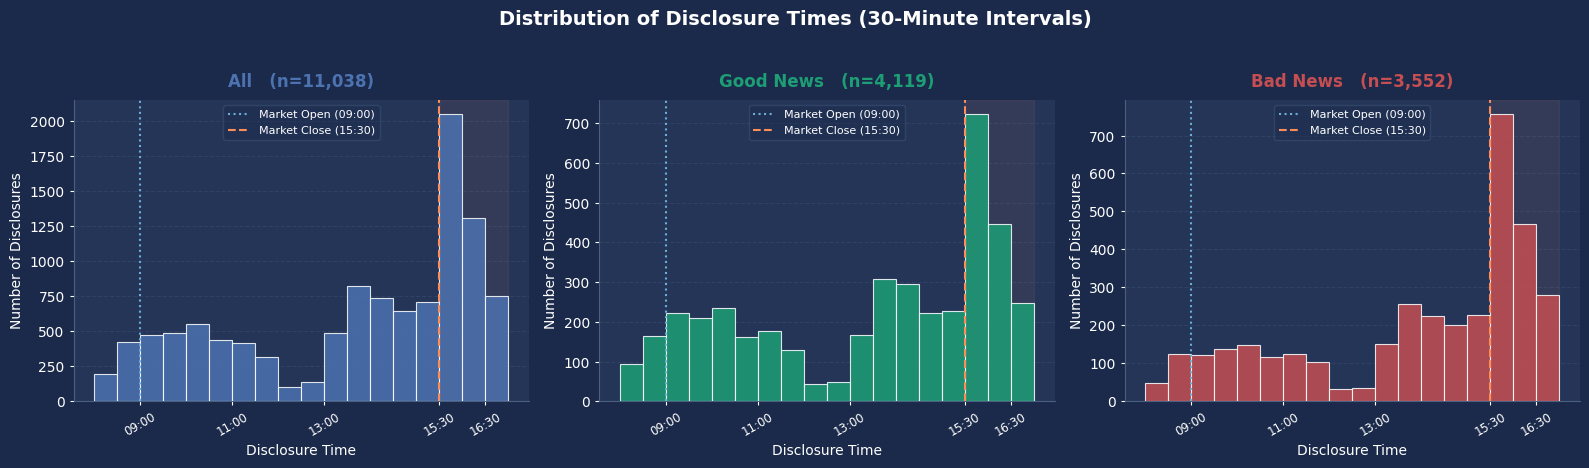

Saved: C:\Users\c2066\OneDrive\바탕 화면\corporate_disclosure_timing\analysis\outputs\01_1_time_histogram.png


In [4]:
def to_minutes(series):
    t = series.dropna().str.split(":", expand=True)
    h = pd.to_numeric(t[0], errors="coerce")
    m = pd.to_numeric(t[1], errors="coerce")
    total = h * 60 + m
    return total[(total >= 480) & (total <= 1020)]

BG_COLOR = "#1B2A4A"  # Navy background

bins = np.arange(480, 1021, 30)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=False)
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle("Distribution of Disclosure Times (30-Minute Intervals)", fontsize=14, fontweight="bold",
             color="#FFFFFF", y=1.03)

COLORS = {"All": "#4C72B0", "Good News": "#1D9E75", "Bad News": "#C44E52"}

datasets = [
    (df[df["timing"].notna()],               "All"),
    (df_hb[df_hb["news"] == "Good News"],    "Good News"),
    (df_hb[df_hb["news"] == "Bad News"],     "Bad News"),
]

for ax, (data, label) in zip(axes, datasets):
    mins = to_minutes(data["rcept_time"])
    color = COLORS[label]

    ax.set_facecolor("#243558")
    ax.hist(mins, bins=bins, color=color, alpha=0.85,
            edgecolor="white", linewidth=0.8, zorder=3)

    ax.axvline(540, color="#6BAED6", linestyle=":", linewidth=1.5,
               label="Market Open (09:00)", zorder=4)
    ax.axvline(930, color="#FC8D59", linestyle="--", linewidth=1.5,
               label="Market Close (15:30)", zorder=4)
    ax.axvspan(930, 1020, alpha=0.08, color="#FC8D59", zorder=2)

    ax.set_title(f"{label}   (n={len(mins):,})", fontsize=12,
                 fontweight="bold", color=color, pad=10)
    ax.set_xlabel("Disclosure Time", fontsize=10, color="#FFFFFF")
    ax.set_ylabel("Number of Disclosures", fontsize=10, color="#FFFFFF")
    ax.set_xticks([540, 660, 780, 930, 990])
    ax.set_xticklabels(["09:00", "11:00", "13:00", "15:30", "16:30"],
                       rotation=30, fontsize=8.5, color="#FFFFFF")
    ax.tick_params(colors="#FFFFFF", length=3)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#4A6080")
    ax.grid(axis="y", linestyle="--", alpha=0.3, color="#4A6080", zorder=1)
    ax.legend(fontsize=8, framealpha=0.4, edgecolor="#4A6080",
              labelcolor="#FFFFFF", facecolor="#1B2A4A")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_1_time_histogram.png",
            dpi=150, bbox_inches="tight", facecolor=BG_COLOR)
plt.show()

print(f"Saved: {OUTPUT_DIR / '01_1_time_histogram.png'}")

## 1-1. Interpretation of the Disclosure Time Distribution Histogram

Across all three histograms, disclosure frequency increases sharply immediately after the market close, particularly during the 15:30–16:00 interval. This pattern suggests that firms tend to release disclosures around or shortly after the end of regular trading hours.

Comparing the **Good News sample (n = 4,119)** with the **Bad News sample (n = 3,552)**, Bad News disclosures appear relatively more concentrated in the post-market period. However, the visual difference is not substantial, and both groups exhibit their highest disclosure frequency immediately after the market closes.

During regular trading hours (09:00–15:30), Good News disclosures appear to be distributed more evenly across time intervals.

However, these histograms display absolute disclosure counts, meaning that differences in sample size between Good News and Bad News are reflected in the visualization. Therefore, the histograms alone are insufficient to determine whether disclosure timing systematically differs by news type. A proportional comparison is required to assess these differences more appropriately.

The statistical significance of these patterns is examined in the subsequent **cross-tabulation and chi-square test analyses**.

Overall, the histograms indicate that the concentration of disclosures immediately after market close is not limited to a particular news type but is a broader feature of disclosure activity. Accordingly, the primary observation at this stage is not that Bad News is necessarily more concentrated after hours, but rather that **post-market disclosure clustering is prevalent across both Good News and Bad News disclosures**.

### 1-2. News Type × Disclosure Timing Cross-Tabulation

=== Counts ===
timing     Pre-market  Intraday  After-hours
news                                        
Good News         330      2460         1737
Bad News          243      1894         1887

=== Percentages (%) ===
timing     Pre-market  Intraday  After-hours
news                                        
Good News         7.3      54.3         38.4
Bad News          6.0      47.1         46.9

Bad News after-hours share: 46.9%
Good News after-hours share: 38.4%
Difference: +8.5 pp


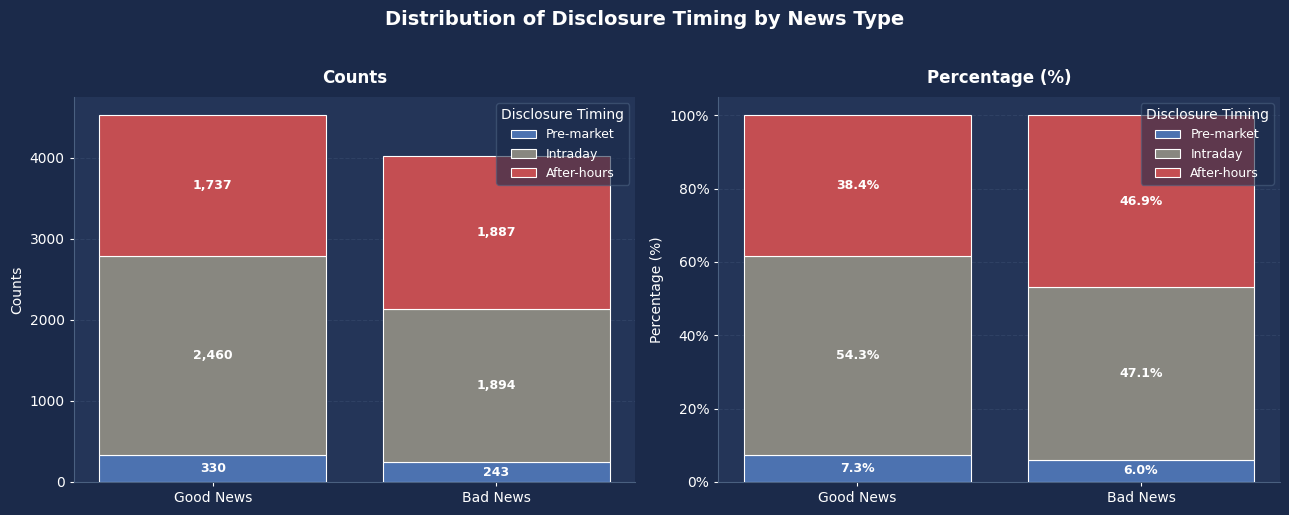

Saved: C:\Users\c2066\OneDrive\바탕 화면\corporate_disclosure_timing\analysis\outputs\01_2_crosstab.png


In [5]:
ct = pd.crosstab(df_hb["news"], df_hb["timing"])
ct = ct.reindex(
    index=["Good News", "Bad News"],
    columns=["Pre-market", "Intraday", "After-hours"]
)  # Explicitly specify row and column order

ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

print("=== Counts ===")
print(ct)

print("\n=== Percentages (%) ===")
print(ct_pct.round(1))

print(f"\nBad News after-hours share: {ct_pct.loc['Bad News', 'After-hours']:.1f}%")
print(f"Good News after-hours share: {ct_pct.loc['Good News', 'After-hours']:.1f}%")
print(
    f"Difference: "
    f"{ct_pct.loc['Bad News', 'After-hours'] - ct_pct.loc['Good News', 'After-hours']:+.1f} pp"
)

BG_COLOR = "#1B2A4A"

PALETTE = {
    "Pre-market": "#4C72B0",
    "Intraday": "#888780",
    "After-hours": "#C44E52"
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor(BG_COLOR)

fig.suptitle(
    "Distribution of Disclosure Timing by News Type",
    fontsize=14,
    fontweight="bold",
    color="#FFFFFF",
    y=1.02
)

for ax, (data, title, fmt) in zip(axes, [
    (ct,     "Counts",         lambda v: f"{int(v):,}"),
    (ct_pct, "Percentage (%)", lambda v: f"{v:.1f}%"),
]):
    ax.set_facecolor("#243558")
    bottom = np.zeros(2)

    for timing, color in PALETTE.items():
        vals = data[timing].values

        bars = ax.bar(
            ["Good News", "Bad News"],
            vals,
            bottom=bottom,  # Consistent with the specified reindex order
            label=timing,
            color=color,
            edgecolor="white",
            linewidth=0.8,
            zorder=3
        )

        for bar, val in zip(bars, vals):
            if val > (80 if title == "Counts" else 4):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    fmt(val),
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="white",
                    fontweight="bold"
                )

        bottom += vals

    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_ylabel(title, fontsize=10)
    ax.tick_params(length=3)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#4A6080")
    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3,
        color="#4A6080",
        zorder=1
    )

    if title == "Percentage (%)":
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())

    ax.legend(title="Disclosure Timing", fontsize=9)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "01_2_crosstab.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR
)

plt.show()

print(f"Saved: {OUTPUT_DIR / '01_2_crosstab.png'}")

## 1-2. Interpretation of the News Type × Disclosure Timing Cross-Tabulation

The most notable result from the cross-tabulation is that **Bad News disclosures had a higher after-hours share than Good News disclosures**.

| News Type | After-Hours Share |
|---|---:|
| Bad News | 46.9% |
| Good News | 38.4% |

Nearly half of Bad News disclosures were released after the market closed, whereas Good News disclosures showed a relatively lower concentration in the after-hours period. The difference between the two groups was approximately **8.5 percentage points**.

In contrast, the share of Intraday disclosures was higher for Good News (**54.3%**) than for Bad News (**47.1%**), a difference of approximately **7.2 percentage points**. This pattern suggests that Good News disclosures tend to be relatively more concentrated during trading hours, while Bad News disclosures tend to be relatively more concentrated after market close.

However, two points should be considered at this stage.

First, the cross-tabulation alone does not establish whether the observed differences are **statistically significant**. This is examined in the following section using a **chi-square test of independence**.

Second, the Pre-market share was slightly higher for Good News (**7.3%**) than for Bad News (**6.0%**). Although this is consistent with Bad News being relatively less concentrated before the market opens, the difference is small and should not be overinterpreted.

Overall, the appropriate interpretation at this stage is that **Bad News disclosures show a relatively greater tendency to be released after market close**. Whether this pattern represents a statistically significant association between news type and disclosure timing is evaluated in the subsequent statistical analysis.

### 1-3. Chi-Square Test of Independence

=== Chi-Square (χ²) Test of Independence ===
Null hypothesis: News type and disclosure timing are independent

χ²=63.6274,  df=2,  p=0.000000  *** (p<0.001)

Standardized residuals (|z|>2 → meaningful contribution):
timing     Pre-market  Intraday  After-hours
news                                        
Bad News        -1.62     -3.42         4.40
Good News        1.53      3.23        -4.15

Positive (+): Observed > Expected  /  Negative (-): Observed < Expected


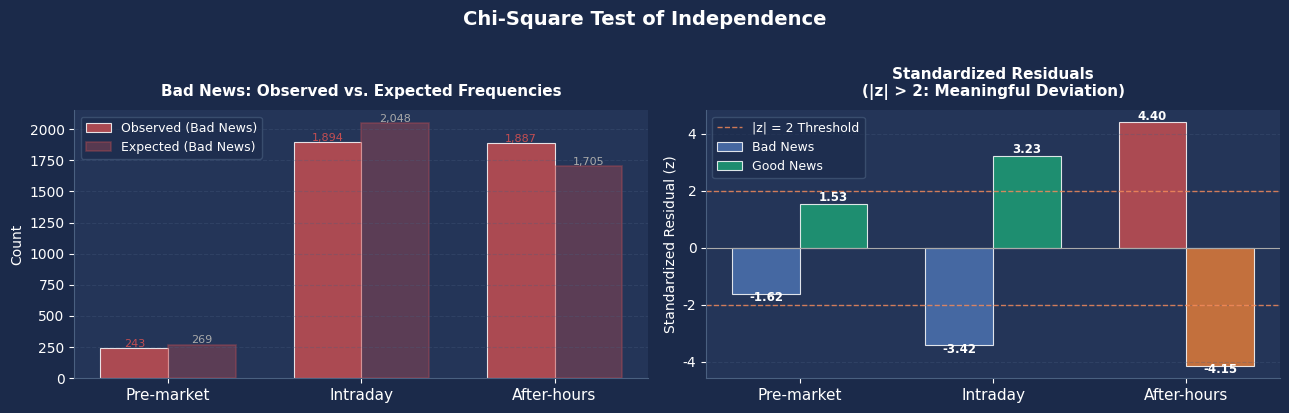

Saved: C:\Users\c2066\OneDrive\바탕 화면\corporate_disclosure_timing\analysis\outputs\01_3_chi2.png


In [6]:
ct = pd.crosstab(df_hb["news"], df_hb["timing"])
ct = ct.reindex(columns=["Pre-market", "Intraday", "After-hours"])
chi2, p, dof, expected = stats.chi2_contingency(ct)

def sig_label(p):
    if p < 0.001: return "*** (p<0.001)"
    if p < 0.01:  return "** (p<0.01)"
    if p < 0.05:  return "* (p<0.05)"
    return "(Not significant)"

print("=== Chi-Square (χ²) Test of Independence ===")
print("Null hypothesis: News type and disclosure timing are independent")
print(f"\nχ²={chi2:.4f},  df={dof},  p={p:.6f}  {sig_label(p)}")

std_resid = (ct.values - expected) / np.sqrt(expected)
sr_df = pd.DataFrame(std_resid.round(2), index=ct.index, columns=ct.columns)

print("\nStandardized residuals (|z|>2 → meaningful contribution):")
print(sr_df)
print("\nPositive (+): Observed > Expected  /  Negative (-): Observed < Expected")

BG_COLOR = "#1B2A4A"

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle(
    "Chi-Square Test of Independence",
    fontsize=14,
    fontweight="bold",
    color="#FFFFFF",
    y=1.02
)

# Left: Observed vs. expected frequencies
ax = axes[0]
ax.set_facecolor("#243558")
x = np.arange(3)
width = 0.35
labels = ["Pre-market", "Intraday", "After-hours"]

bars_actual = ax.bar(
    x - width/2,
    ct.loc["Bad News"].values,
    width,
    label="Observed (Bad News)",
    color="#C44E52",
    alpha=0.85,
    edgecolor="white",
    linewidth=0.8
)

bad_news_idx = ct.index.get_loc("Bad News")

bars_expected = ax.bar(
    x + width/2,
    expected[bad_news_idx],
    width,
    label="Expected (Bad News)",
    color="#C44E52",
    alpha=0.35,
    edgecolor="#C44E52",
    linewidth=1.2
)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("Count", fontsize=10)
ax.set_title(
    "Bad News: Observed vs. Expected Frequencies",
    fontsize=11,
    fontweight="bold",
    pad=10
)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#4A6080")
ax.grid(axis="y", linestyle="--", alpha=0.3, color="#4A6080")
ax.legend(fontsize=9)

for bar in bars_actual:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 10,
        f"{int(bar.get_height()):,}",
        ha="center",
        fontsize=8,
        color="#C44E52"
    )

for val, bar in zip(expected[bad_news_idx], bars_expected):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        val + 10,
        f"{int(val):,}",
        ha="center",
        fontsize=8,
        color="#AAAAAA"
    )

# Right: Standardized residuals
ax = axes[1]
ax.set_facecolor("#243558")

bad_news_idx = ct.index.get_loc("Bad News")
good_news_idx = ct.index.get_loc("Good News")

resid_bad = std_resid[bad_news_idx]
resid_good = std_resid[good_news_idx]

bars_bad = ax.bar(
    x - width/2,
    resid_bad,
    width,
    label="Bad News",
    color=["#C44E52" if v > 0 else "#4C72B0" for v in resid_bad],
    alpha=0.85,
    edgecolor="white",
    linewidth=0.8
)

bars_good = ax.bar(
    x + width/2,
    resid_good,
    width,
    label="Good News",
    color=["#1D9E75" if v > 0 else "#E07B39" for v in resid_good],
    alpha=0.85,
    edgecolor="white",
    linewidth=0.8
)

ax.axhline(
    y=2,
    color="#FC8D59",
    linestyle="--",
    linewidth=1.0,
    alpha=0.8,
    label="|z| = 2 Threshold"
)
ax.axhline(
    y=-2,
    color="#FC8D59",
    linestyle="--",
    linewidth=1.0,
    alpha=0.8
)
ax.axhline(y=0, color="#AAAAAA", linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("Standardized Residual (z)", fontsize=10)
ax.set_title(
    "Standardized Residuals\n(|z| > 2: Meaningful Deviation)",
    fontsize=11,
    fontweight="bold",
    pad=10
)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#4A6080")
ax.grid(axis="y", linestyle="--", alpha=0.3, color="#4A6080")
ax.legend(fontsize=9)

for bar in bars_bad:
    v = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        v + 0.1 if v >= 0 else v - 0.25,
        f"{v:.2f}",
        ha="center",
        fontsize=8.5,
        fontweight="bold"
    )

for bar in bars_good:
    v = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        v + 0.1 if v >= 0 else v - 0.25,
        f"{v:.2f}",
        ha="center",
        fontsize=8.5,
        fontweight="bold"
    )

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "01_3_chi2.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR
)

plt.show()

print(f"Saved: {OUTPUT_DIR / '01_3_chi2.png'}")

## 1-3. Interpretation of the Chi-Square Test of Independence

The chi-square test of independence indicates a **statistically significant association between news type and disclosure timing**.

```text
χ² = 63.63
df = 2
p < 0.001
```

Therefore, the null hypothesis that **news type and disclosure timing are independent** is rejected. This result provides statistical evidence that the distribution of disclosure timing differs between Good News and Bad News disclosures.

The **standardized residuals** provide further insight into which timing categories contribute to this association.

In the **After-hours** category, Bad News disclosures exhibit a large positive standardized residual (**z = +4.40**), indicating that more Bad News disclosures occurred after market close than would be expected under independence. In contrast, Good News disclosures show a negative residual (**z = -4.15**), indicating fewer After-hours Good News disclosures than expected.

The opposite pattern is observed for **Intraday** disclosures. Bad News disclosures occur less frequently than expected (**z = -3.42**), whereas Good News disclosures occur more frequently than expected (**z = +3.23**).

For the **Pre-market** category, the standardized residuals for both Bad News (**z = -1.62**) and Good News (**z = +1.53**) remain within the |z| < 2 range, indicating no substantial deviation from the expected frequencies.

Overall, the results provide statistical evidence that **Bad News disclosures are relatively more concentrated After-hours, whereas Good News disclosures are relatively more concentrated Intraday**. This supports the approximately **8.5 percentage-point difference in the After-hours disclosure share** observed in the preceding cross-tabulation analysis.

However, the chi-square test establishes an **association** between news type and disclosure timing; it does not by itself demonstrate that firms strategically choose disclosure times. Whether the observed timing pattern is consistent with strategic disclosure behavior requires further examination using regression analysis and additional empirical tests.

### 1-4. Day of Week × Disclosure Timing Heatmap

=== Bad News Share by Day of Week and Disclosure Timing (%) ===
timing         Pre-market  Intraday  After-hours
weekday_label                                   
Monday               32.7      38.8         49.0
Tuesday              44.0      44.5         52.9
Wednesday            41.6      44.2         52.4
Thursday             44.8      41.2         50.8
Friday               43.0      48.1         54.5


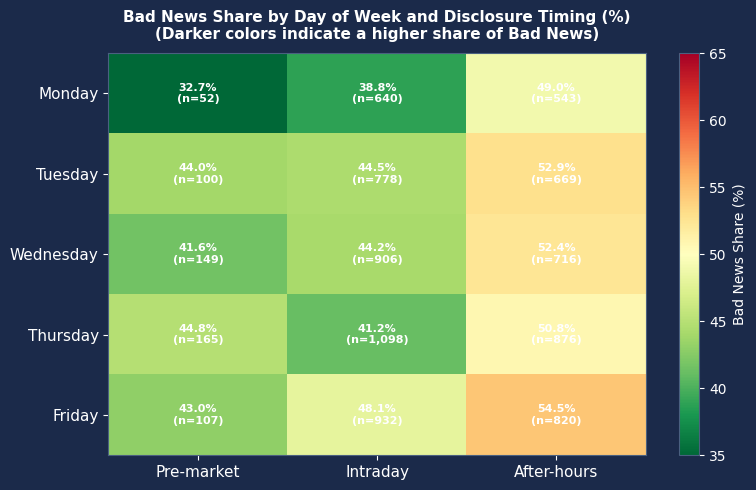

Saved: C:\Users\c2066\OneDrive\바탕 화면\corporate_disclosure_timing\analysis\outputs\01_4_heatmap.png


In [7]:
BG_COLOR = "#1B2A4A"

d = df_hb.copy()

d["weekday_label"] = d["weekday"].map({
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday"
})

pct = d.pivot_table(
    values="news",
    index="weekday_label",
    columns="timing",
    aggfunc=lambda x: (x == "Bad News").sum() / len(x) * 100
).reindex(
    index=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"],
    columns=["Pre-market", "Intraday", "After-hours"]
)

cnt = d.pivot_table(
    values="news",
    index="weekday_label",
    columns="timing",
    aggfunc="count"
).reindex(
    index=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"],
    columns=["Pre-market", "Intraday", "After-hours"]
)

print("=== Bad News Share by Day of Week and Disclosure Timing (%) ===")
print(pct.round(1))

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor("#243558")

im = ax.imshow(
    pct.values,
    cmap="RdYlGn_r",
    vmin=35,
    vmax=65,
    aspect="auto"
)

ax.set_xticks(range(3))
ax.set_xticklabels(
    ["Pre-market", "Intraday", "After-hours"],
    fontsize=11
)

ax.set_yticks(range(5))
ax.set_yticklabels(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"],
    fontsize=11
)

ax.set_title(
    "Bad News Share by Day of Week and Disclosure Timing (%)\n"
    "(Darker colors indicate a higher share of Bad News)",
    fontsize=11,
    fontweight="bold",
    pad=10
)

for i in range(5):
    for j in range(3):
        v, c = pct.values[i, j], cnt.values[i, j]

        if not np.isnan(v):
            ax.text(
                j,
                i,
                f"{v:.1f}%\n(n={int(c):,})",
                ha="center",
                va="center",
                fontsize=8,
                color="white",
                fontweight="bold"
            )

ax.spines[["top", "right", "left", "bottom"]].set_color("#4A6080")

cbar = plt.colorbar(im, ax=ax)
cbar.ax.yaxis.set_tick_params(color="#FFFFFF")
cbar.outline.set_edgecolor("#4A6080")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#FFFFFF")
cbar.set_label("Bad News Share (%)", color="#FFFFFF")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "01_4_heatmap.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR
)

plt.show()

print(f"Saved: {OUTPUT_DIR / '01_4_heatmap.png'}")

## 1-4. Interpretation of the Day of Week × Disclosure Timing Heatmap

The heatmap analysis, which jointly considers the day of the week and disclosure timing, shows that the **share of Bad News disclosures is consistently higher After-hours than Intraday across all weekdays**. The pattern of After-hours > Intraday is maintained throughout the week, suggesting that the concentration of Bad News disclosures after market close may represent a relatively systematic pattern rather than a phenomenon confined to a particular day.

In particular, the **Friday After-hours** category recorded a Bad News share of **54.5%**, the highest among all 15 day-of-week × timing combinations. This pattern is directionally similar to the **"Friday evening clustering"** of corporate disclosures documented in prior research on the U.S. market by Michaely et al. (2016a).

In contrast, the **Monday Pre-market** category showed the lowest Bad News share at **32.7%**, indicating that Bad News disclosures were relatively less prevalent before the market opened at the beginning of the week.

However, the Pre-market categories generally contain smaller sample sizes and exhibit greater variation across weekdays. The share of Bad News in the Pre-market period ranged from **32.7% to 44.8%**, with some cells containing relatively few observations (**n = 52–165**). In particular, the Monday Pre-market category includes only approximately **52 observations**, so its estimated share should be interpreted with caution.

Overall, the heatmap provides a relatively clear visual pattern in which **Bad News disclosures are more concentrated After-hours**. However, the heatmap alone does not establish whether the day-of-week effect is independently statistically significant. This issue is examined more rigorously in the following section using the **Kruskal–Wallis test**.

### 1-5. Kruskal–Wallis Test

=== Kruskal–Wallis Test ===
Null hypothesis: The distributions of Bad News shares are identical across the three timing categories
  Pre-market: Mean 41.6%  Median 42.9%  n=55
  Intraday: Mean 50.1%  Median 47.4%  n=71
  After-hours: Mean 51.0%  Median 52.0%  n=64

H=8.1470,  p=0.017018  * (p<0.05)

Post-hoc tests (Mann–Whitney U, Bonferroni α=0.0167):
  Pre-market vs Intraday: U=1592.0,  p=0.0764,  p_adj=0.2293  (Not significant)
  Pre-market vs After-hours: U=1239.5,  p=0.0056,  p_adj=0.0167  * (p<0.05)
  Intraday vs After-hours: U=1974.5,  p=0.1904,  p_adj=0.5713  (Not significant)


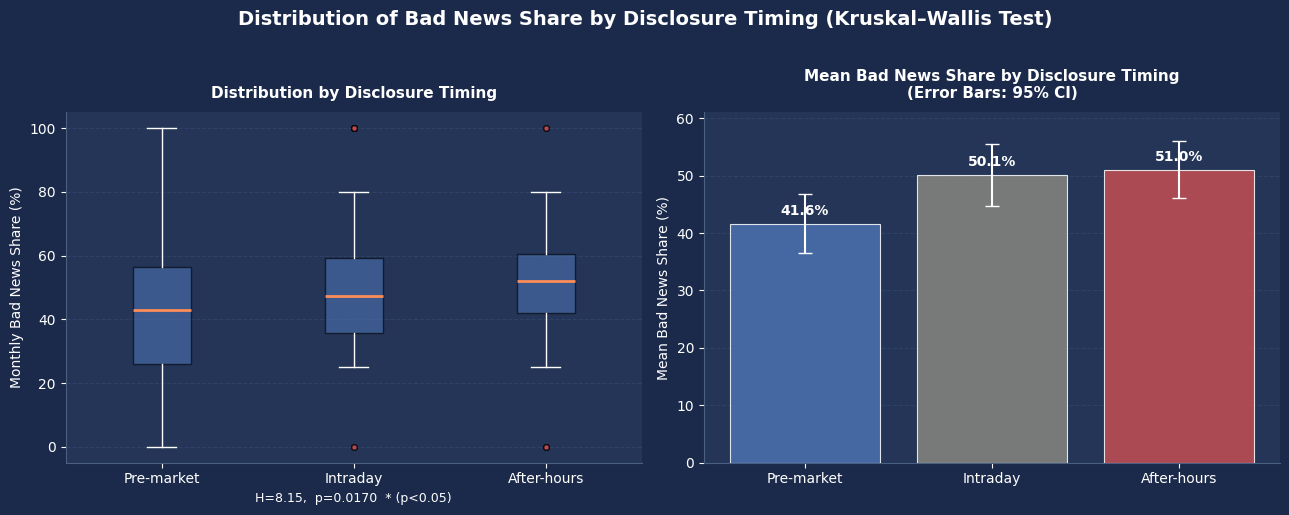

Saved: C:\Users\c2066\OneDrive\바탕 화면\corporate_disclosure_timing\analysis\outputs\01_5_kruskal.png


In [8]:
BG_COLOR = "#1B2A4A"

d = df_hb.copy()
d["ym"] = d["rcept_dt"].str[:6]

ym_pct = d.groupby(["ym", "timing"])["news"].apply(
    lambda x: (x == "Bad News").sum() / len(x) * 100
).reset_index()
ym_pct.columns = ["ym", "timing", "bad_pct"]

groups = {
    t: ym_pct[ym_pct["timing"] == t]["bad_pct"].values
    for t in ["Pre-market", "Intraday", "After-hours"]
}

h_stat, p = stats.kruskal(*groups.values())

print("=== Kruskal–Wallis Test ===")
print("Null hypothesis: The distributions of Bad News shares are identical across the three timing categories")

for t, v in groups.items():
    print(f"  {t}: Mean {v.mean():.1f}%  Median {np.median(v):.1f}%  n={len(v)}")

print(f"\nH={h_stat:.4f},  p={p:.6f}  {sig_label(p)}")

pairs = list(combinations(["Pre-market", "Intraday", "After-hours"], 2))
alpha_adj = 0.05 / len(pairs)

print(f"\nPost-hoc tests (Mann–Whitney U, Bonferroni α={alpha_adj:.4f}):")

for a, b in pairs:
    u, p_mw = stats.mannwhitneyu(
        groups[a],
        groups[b],
        alternative="two-sided"
    )
    p_adj = min(p_mw * len(pairs), 1.0)

    print(
        f"  {a} vs {b}: "
        f"U={u:.1f},  p={p_mw:.4f},  p_adj={p_adj:.4f}  {sig_label(p_adj)}"
    )

# Visualization: Distribution of Bad News shares by disclosure timing
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor(BG_COLOR)

fig.suptitle(
    "Distribution of Bad News Share by Disclosure Timing (Kruskal–Wallis Test)",
    fontsize=14,
    fontweight="bold",
    color="#FFFFFF",
    y=1.02
)

# Left: Boxplot
ax = axes[0]
ax.set_facecolor("#243558")

bp = ax.boxplot(
    [
        groups["Pre-market"],
        groups["Intraday"],
        groups["After-hours"]
    ],
    tick_labels=["Pre-market", "Intraday", "After-hours"],
    patch_artist=True,
    boxprops=dict(facecolor="#4C72B0", alpha=0.6),
    medianprops=dict(color="#FC8D59", linewidth=2),
    whiskerprops=dict(color="#FFFFFF", linewidth=1),
    capprops=dict(color="#FFFFFF", linewidth=1),
    flierprops=dict(
        marker="o",
        markerfacecolor="#C44E52",
        markersize=4,
        alpha=0.5
    )
)

ax.set_ylabel("Monthly Bad News Share (%)", fontsize=10)
ax.set_title(
    "Distribution by Disclosure Timing",
    fontsize=11,
    fontweight="bold",
    pad=10
)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#4A6080")
ax.grid(axis="y", linestyle="--", alpha=0.3, color="#4A6080")
ax.set_xlabel(
    f"H={h_stat:.2f},  p={p:.4f}  {sig_label(p)}",
    fontsize=9
)

# Right: Mean comparison with 95% confidence intervals
ax = axes[1]
ax.set_facecolor("#243558")

timings = ["Pre-market", "Intraday", "After-hours"]
means = [groups[t].mean() for t in timings]
cis = [
    1.96 * groups[t].std() / np.sqrt(len(groups[t]))
    for t in timings
]
colors = [C_BEFORE, C_DURING, C_AFTER]

bars = ax.bar(
    timings,
    means,
    color=colors,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.8,
    zorder=3
)

ax.errorbar(
    timings,
    means,
    yerr=cis,
    fmt="none",
    color="#FFFFFF",
    capsize=5,
    linewidth=1.5,
    zorder=4
)

for bar, mean in zip(bars, means):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1.5,
        f"{mean:.1f}%",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

ax.set_ylabel("Mean Bad News Share (%)", fontsize=10)
ax.set_title(
    "Mean Bad News Share by Disclosure Timing\n(Error Bars: 95% CI)",
    fontsize=11,
    fontweight="bold",
    pad=10
)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#4A6080")
ax.grid(axis="y", linestyle="--", alpha=0.3, color="#4A6080", zorder=1)
ax.set_ylim(0, max(means) + 10)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "01_5_kruskal.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR
)

plt.show()

print(f"Saved: {OUTPUT_DIR / '01_5_kruskal.png'}")

## 1-5. Interpretation of the Kruskal–Wallis Test

The Kruskal–Wallis test indicates a **statistically significant difference in the distribution of Bad News shares across disclosure timing categories**.

```text
H = 8.15
p = 0.017
```

Therefore, the null hypothesis that **the distributions of Bad News shares are identical across the three disclosure timing categories** is rejected. This provides statistical evidence that the distribution of Bad News shares varies across disclosure timing categories.

However, the **post-hoc tests** show that the statistically significant difference is limited to a specific pair of timing categories.

| Comparison | Adjusted p-value |
|---|---:|
| Pre-market vs. After-hours | 0.017 |
| Pre-market vs. Intraday | 0.229 |
| Intraday vs. After-hours | 0.571 |

The only statistically significant pairwise difference is between the **Pre-market and After-hours** periods. The mean Bad News share was **41.6% for Pre-market disclosures** and **51.0% for After-hours disclosures**, indicating a statistically significant difference between these two categories.

In contrast, neither the **Pre-market vs. Intraday** nor the **Intraday vs. After-hours** comparison was statistically significant. In particular, the adjusted p-value for the Intraday vs. After-hours comparison was **0.571**, providing little evidence of a difference between these two timing categories.

Accordingly, the tendency for Bad News disclosures to be relatively more concentrated After-hours is supported when compared with the Pre-market period, but is **not strongly supported when After-hours disclosures are compared with Intraday disclosures**.

The Pre-market category also contains a relatively small number of monthly observations (**n = 55**) and exhibits comparatively high variability. The boxplot shows several outlying observations, suggesting that estimates for the Pre-market category may be less stable and should therefore be interpreted with caution.

Overall, although the **Kruskal–Wallis test is statistically significant**, the post-hoc results indicate that the difference is driven primarily by the contrast between the Pre-market and After-hours periods. Compared with the stronger association identified by the chi-square test (**p < 0.001**), this provides more limited evidence of differences across timing categories. Taken together, the results suggest that **disclosure timing patterns exist, but the distinction between Intraday and After-hours Bad News shares is relatively limited in this monthly distribution analysis**.

### 1-6. KOSPI vs. KOSDAQ Comparison

=== KOSPI vs. KOSDAQ Comparison of After-Hours Bad News Share (Mann–Whitney U) ===
Null hypothesis: The distributions of After-hours Bad News shares are identical across the two markets

KOSPI  : Mean 20.13%  Median 18.46%  n=74
KOSDAQ : Mean 22.24%  Median 21.75%  n=62

U=2018.5,  p=0.228871  (Not significant)


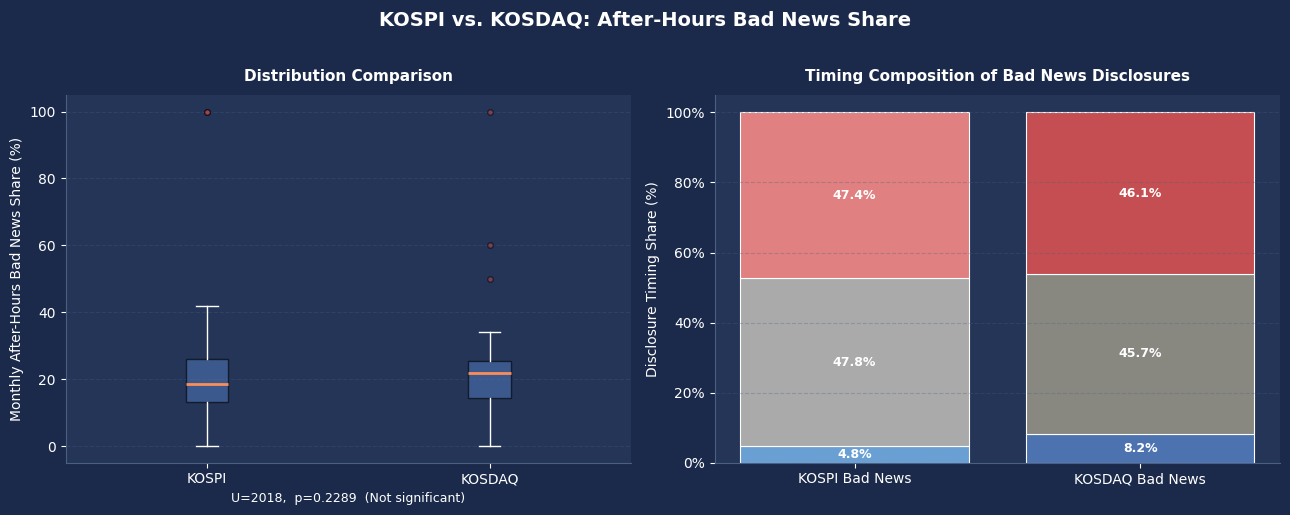

Saved: C:\Users\c2066\OneDrive\바탕 화면\corporate_disclosure_timing\analysis\outputs\01_6_market_comparison.png


In [9]:
BG_COLOR = "#1B2A4A"

d = df_hb.copy()
d["ym"] = d["rcept_dt"].str[:6]

bad_after = d.groupby(["market", "ym"]).apply(
    lambda g: ((g["news"] == "Bad News") & (g["timing"] == "After-hours")).sum() / max(len(g), 1) * 100
).reset_index()
bad_after.columns = ["market", "ym", "bad_after_pct"]

kospi  = bad_after[bad_after["market"] == "KOSPI"]["bad_after_pct"]
kosdaq = bad_after[bad_after["market"] == "KOSDAQ"]["bad_after_pct"]
u_stat, p = stats.mannwhitneyu(kospi, kosdaq, alternative="two-sided")

print("=== KOSPI vs. KOSDAQ Comparison of After-Hours Bad News Share (Mann–Whitney U) ===")
print("Null hypothesis: The distributions of After-hours Bad News shares are identical across the two markets")
print(f"\nKOSPI  : Mean {kospi.mean():.2f}%  Median {kospi.median():.2f}%  n={len(kospi)}")
print(f"KOSDAQ : Mean {kosdaq.mean():.2f}%  Median {kosdaq.median():.2f}%  n={len(kosdaq)}")
print(f"\nU={u_stat:.1f},  p={p:.6f}  {sig_label(p)}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle(
    "KOSPI vs. KOSDAQ: After-Hours Bad News Share",
    fontsize=14,
    fontweight="bold",
    color="#FFFFFF",
    y=1.02
)

# Left: Boxplot
ax = axes[0]
ax.set_facecolor("#243558")
bp = ax.boxplot(
    [kospi, kosdaq],
    tick_labels=["KOSPI", "KOSDAQ"],
    patch_artist=True,
    boxprops=dict(facecolor="#4C72B0", alpha=0.6),
    medianprops=dict(color="#FC8D59", linewidth=2),
    whiskerprops=dict(color="#FFFFFF", linewidth=1),
    capprops=dict(color="#FFFFFF", linewidth=1),
    flierprops=dict(
        marker="o",
        markerfacecolor="#C44E52",
        markersize=4,
        alpha=0.5
    )
)
ax.set_ylabel("Monthly After-Hours Bad News Share (%)", fontsize=10)
ax.set_title("Distribution Comparison", fontsize=11, fontweight="bold", pad=10)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#4A6080")
ax.grid(axis="y", linestyle="--", alpha=0.3, color="#4A6080")
ax.set_xlabel(f"U={u_stat:.0f},  p={p:.4f}  {sig_label(p)}", fontsize=9)

# Right: Timing composition of Bad News disclosures (stacked bar)
ax = axes[1]
ax.set_facecolor("#243558")

timing_order = ["Pre-market", "Intraday", "After-hours"]

light = {
    "Pre-market": "#6A9FD4",
    "Intraday": "#AAAAAA",
    "After-hours": "#E08080"
}

dark = {
    "Pre-market": C_BEFORE,
    "Intraday": C_DURING,
    "After-hours": C_AFTER
}

for i, (market, palette) in enumerate([
    ("KOSPI", light),
    ("KOSDAQ", dark)
]):
    sub = df_hb[df_hb["market"] == market]

    ct = sub.groupby(["news", "timing"]).size().unstack(fill_value=0)
    ct = ct.reindex(columns=timing_order, fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

    bottom = 0

    for t in timing_order:
        val = ct_pct.loc["Bad News", t] if "Bad News" in ct_pct.index else 0

        ax.bar(
            i,
            val,
            bottom=bottom,
            color=palette[t],
            edgecolor="white",
            linewidth=0.8
        )

        if val > 3:
            ax.text(
                i,
                bottom + val / 2,
                f"{val:.1f}%",
                ha="center",
                va="center",
                fontsize=9,
                color="white",
                fontweight="bold"
            )

        bottom += val

ax.set_xticks([0, 1])
ax.set_xticklabels(["KOSPI Bad News", "KOSDAQ Bad News"])
ax.set_ylabel("Disclosure Timing Share (%)", fontsize=10)
ax.set_title(
    "Timing Composition of Bad News Disclosures",
    fontsize=11,
    fontweight="bold",
    pad=10
)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#4A6080")
ax.grid(axis="y", linestyle="--", alpha=0.3, color="#4A6080", zorder=1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "01_6_market_comparison.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR
)

plt.show()

print(f"Saved: {OUTPUT_DIR / '01_6_market_comparison.png'}")

## 1-6. Interpretation of the KOSPI vs. KOSDAQ Comparison

The comparison of the After-hours Bad News share between the KOSPI and KOSDAQ markets indicates that the difference between the two markets is **not statistically significant**.

```text
U = 2018.5
p = 0.229
```

Therefore, the null hypothesis that **the distributions of After-hours Bad News shares are identical between KOSPI and KOSDAQ** cannot be rejected. In other words, there is insufficient statistical evidence that After-hours Bad News disclosure patterns differ systematically between the two markets.

Numerically, the mean After-hours Bad News share was **22.24% for KOSDAQ** and **20.13% for KOSPI**, representing a difference of approximately **2.1 percentage points**. However, this difference did not reach statistical significance.

The stacked bar analysis also shows that the timing composition of Bad News disclosures is broadly similar across the two markets.

| Market | After-hours Share of Bad News Disclosures |
|---|---:|
| KOSPI | 47.4% |
| KOSDAQ | 46.1% |

Thus, in both KOSPI and KOSDAQ, approximately half of Bad News disclosures were released After-hours, indicating a similar timing pattern across the two markets.

This finding does not support the initial hypothesis that **After-hours Bad News disclosure patterns may be stronger in KOSDAQ, where retail investor participation is relatively high**. Although such a market-level difference was theoretically plausible, the empirical results show little evidence of a meaningful distinction between KOSPI and KOSDAQ in this respect.

Overall, **market classification (KOSPI vs. KOSDAQ) does not appear to be a major factor explaining After-hours Bad News disclosure patterns** in this analysis. Instead, the similarity across the two markets suggests that the observed After-hours disclosure pattern may be more broadly shared across the Korean equity market rather than being specific to one market segment.

### 1-7. Trend in the After-Hours Bad News Share by Year

=== Annual After-Hours Disclosure Share ===
 year  total  bad_after  bad_pct  good_pct
 2019  783.0      188.0     51.5      39.7
 2020 1175.0      247.0     45.5      37.8
 2021 1222.0      242.0     44.0      37.6
 2022 1270.0      284.0     46.5      37.2
 2023 1351.0      306.0     46.6      39.6
 2024 1357.0      330.0     49.5      38.8
 2025 1393.0      290.0     45.9      38.2


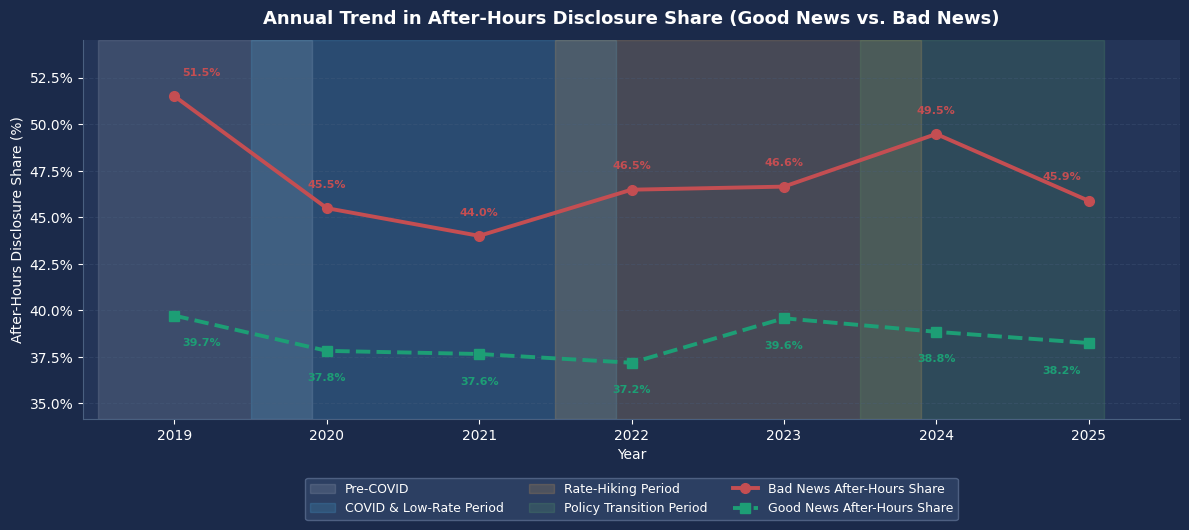

Saved: C:\Users\c2066\OneDrive\바탕 화면\corporate_disclosure_timing\analysis\outputs\01_7_yearly_trend.png


In [10]:
BG_COLOR = "#1B2A4A"

yearly = df_hb.groupby("year").apply(lambda g: pd.Series({
    "total"     : len(g),
    "bad_after" : ((g["news"] == "Bad News") & (g["timing"] == "After-hours")).sum(),
    "good_after": ((g["news"] == "Good News") & (g["timing"] == "After-hours")).sum(),
    "bad_pct"   : ((g["news"] == "Bad News") & (g["timing"] == "After-hours")).sum()
                  / max(g["news"].eq("Bad News").sum(), 1) * 100,
    "good_pct"  : ((g["news"] == "Good News") & (g["timing"] == "After-hours")).sum()
                  / max(g["news"].eq("Good News").sum(), 1) * 100,
})).reset_index()

print("=== Annual After-Hours Disclosure Share ===")

print(
    yearly[["year", "total", "bad_after", "bad_pct", "good_pct"]]
    .round({"bad_pct": 1, "good_pct": 1})
    .to_string(index=False)
)

years = yearly["year"].values

fig, ax = plt.subplots(figsize=(12, 6))

fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor("#243558")

# ------------------------------------------------------------
# Highlight major market periods
# ------------------------------------------------------------

periods = [
    (2019, 2019.9, "#BFC5D2", "Pre-COVID"),                 # Light gray
    (2020, 2021.9, "#4FC3F7", "COVID & Low-Rate Period"),  # Light cyan
    (2022, 2023.9, "#FFB74D", "Rate-Hiking Period"),       # Orange
    (2024, 2025.1, "#66BB6A", "Policy Transition Period"), # Mint green
]

for x0, x1, color, label in periods:
    ax.axvspan(
        x0 - 0.5,
        x1,
        alpha=0.16,
        color=color,
        label=label,
        zorder=1
    )

# ------------------------------------------------------------
# Line plots
# ------------------------------------------------------------

ax.plot(
    years,
    yearly["bad_pct"],
    "o-",
    color=C_BAD,
    linewidth=2.8,
    markersize=7,
    label="Bad News After-Hours Share",
    zorder=3
)

ax.plot(
    years,
    yearly["good_pct"],
    "s--",
    color=C_GOOD,
    linewidth=2.8,
    markersize=7,
    label="Good News After-Hours Share",
    zorder=3
)

# ------------------------------------------------------------
# Data labels
# ------------------------------------------------------------

for i, row in yearly.iterrows():

    x = row["year"]
    y_bad = row["bad_pct"]
    y_good = row["good_pct"]

    # Adjust alignment for labels at both ends
    if i == 0:
        ha = "left"
        x_offset = 0.05
    elif i == len(yearly) - 1:
        ha = "right"
        x_offset = -0.05
    else:
        ha = "center"
        x_offset = 0

    # Bad News label (above)
    ax.annotate(
        f"{y_bad:.1f}%",
        xy=(x, y_bad),
        xytext=(x + x_offset, y_bad + 1.0),
        textcoords="data",
        ha=ha,
        va="bottom",
        fontsize=8,
        color=C_BAD,
        fontweight="bold",
        zorder=5
    )

    # Good News label (below)
    ax.annotate(
        f"{y_good:.1f}%",
        xy=(x, y_good),
        xytext=(x + x_offset, y_good - 1.2),
        textcoords="data",
        ha=ha,
        va="top",
        fontsize=8,
        color=C_GOOD,
        fontweight="bold",
        zorder=5
    )

# ------------------------------------------------------------
# Axis limits
# ------------------------------------------------------------

y_min = min(
    yearly["bad_pct"].min(),
    yearly["good_pct"].min()
) - 3.0

y_max = max(
    yearly["bad_pct"].max(),
    yearly["good_pct"].max()
) + 3.0

ax.set_ylim(y_min, y_max)

ax.set_xlim(
    years[0] - 0.6,
    years[-1] + 0.6
)

# ------------------------------------------------------------
# Axes and title
# ------------------------------------------------------------

ax.set_xticks(years)

ax.set_xlabel("Year", fontsize=10)

ax.set_ylabel(
    "After-Hours Disclosure Share (%)",
    fontsize=10
)

ax.set_title(
    "Annual Trend in After-Hours Disclosure Share (Good News vs. Bad News)",
    fontsize=13,
    fontweight="bold",
    pad=12
)

ax.yaxis.set_major_formatter(
    mtick.PercentFormatter()
)

# ------------------------------------------------------------
# Remove duplicate legend entries
# ------------------------------------------------------------

handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))

legend = ax.legend(
    unique.values(),
    unique.keys(),

    # Position the legend below the chart
    loc="upper center",
    bbox_to_anchor=(0.5, -0.14),

    fontsize=9,
    ncol=3,
    framealpha=0.75
)

# Improve legend box styling
legend.get_frame().set_facecolor("#32476B")
legend.get_frame().set_edgecolor("#5D7092")

# ------------------------------------------------------------
# Style
# ------------------------------------------------------------

ax.spines[["top", "right"]].set_visible(False)

ax.spines[["left", "bottom"]].set_color("#4A6080")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3,
    color="#4A6080",
    zorder=1
)

# Reserve space for the legend
plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.savefig(
    OUTPUT_DIR / "01_7_yearly_trend.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR
)

plt.show()

print(
    f"Saved: {OUTPUT_DIR / '01_7_yearly_trend.png'}"
)

## 1-7. Interpretation of the Annual Trend in After-Hours Bad News Disclosures

The annual trend analysis shows that the **After-hours disclosure share of Bad News remained consistently higher than that of Good News throughout the entire 2019–2025 period**.

The After-hours share of Bad News disclosures ranged from approximately **44% to 52%**, whereas the corresponding share for Good News remained relatively stable at approximately **37% to 40%**. The persistent gap between the two groups over the seven-year period suggests that the tendency for Bad News disclosures to occur After-hours may represent a recurring pattern rather than a short-term phenomenon.

Among individual years, **2019 recorded the highest After-hours Bad News share at 51.5%**. However, the 2019 sample contained **783 disclosures**, fewer than in the other years (**1,175–1,393 disclosures**), so the estimate for that year should be interpreted with some caution.

During the **COVID-19 and low-interest-rate period of 2020–2021**, the After-hours Bad News share declined to approximately **44%–46%**. It subsequently increased during and after the **2022–2023 rate-hiking period**, reaching **49.5% in 2024**, the second-highest level observed during the study period. In 2025, the share declined again to **45.9%**.

In contrast, the After-hours share of Good News disclosures remained comparatively stable within the **37%–40% range** throughout the study period. Compared with Bad News disclosures, Good News disclosures exhibited less year-to-year variation. While this pattern could suggest that the timing of Good News disclosures is less sensitive to changing market conditions, the descriptive evidence alone is insufficient to establish such a relationship.

Overall, despite year-to-year fluctuations, the gap in After-hours disclosure shares between Bad News and Good News—approximately **7–12 percentage points**—persisted throughout the analysis period. This temporal consistency provides descriptive evidence that the difference in disclosure timing is not confined to a single year or market environment.

However, the figure alone cannot determine whether the annual variation is attributable to **market volatility, changes in disclosure volume, macroeconomic conditions, or other firm- and market-level factors**. Accordingly, the year-specific patterns should be interpreted descriptively, with potential explanatory factors examined more rigorously through subsequent regression analyses and additional controls.

# Analysis ① Summary of Results

---

## Q1. Do Korean Firms Disclose Bad News More Frequently After Market Close?

The results indicate that **Bad News disclosures are relatively more concentrated After-hours**, although the difference between Intraday and After-hours disclosures is limited.

| Test | Result | Conclusion |
|---|---|---|
| Chi-square test | χ² = 63.63, p < 0.001 | Significant association between news type and disclosure timing |
| Kruskal–Wallis test | H = 8.15, p = 0.017 | Significant difference in the distribution of Bad News shares across timing categories |
| Post-hoc test (Pre-market vs. After-hours) | p_adj = 0.017 | Significant difference |
| Post-hoc test (Intraday vs. After-hours) | p_adj = 0.571 | No significant difference |

Most notably, **46.9% of Bad News disclosures occurred After-hours**, compared with **38.4% of Good News disclosures**, representing a difference of approximately **8.5 percentage points**.

The standardized residual analysis from the chi-square test further showed that the **Bad News × After-hours** combination had the largest positive residual (**z = +4.40**), indicating that Bad News disclosures occurred After-hours more frequently than expected under the assumption of independence.

However, the Kruskal–Wallis post-hoc analysis found no statistically significant difference between the Intraday and After-hours categories (**p_adj = 0.571**). Therefore, the results should not be interpreted as showing that Bad News disclosures are overwhelmingly concentrated After-hours. A more appropriate interpretation is that **Bad News disclosures are relatively more prevalent After-hours than Pre-market, while the difference between Intraday and After-hours is not statistically strong in the monthly distribution analysis**.

---

## Hypothesis Testing Results

### Hypothesis 1. Bad News Disclosures Are Significantly Concentrated After Market Close

> **Partially supported.**
>
> The chi-square test identified a statistically significant association between Bad News and After-hours disclosure timing. However, the Kruskal–Wallis post-hoc analysis did not identify a statistically significant difference between the Intraday and After-hours categories.

---

### Hypothesis 3. The Pattern Is Stronger in KOSDAQ Than in KOSPI

> **Not supported.**
>
> The Mann–Whitney U test found no statistically significant difference in the After-hours Bad News share between KOSPI and KOSDAQ (**p = 0.229**).
>
> This suggests that the After-hours Bad News disclosure pattern is not specific to one market segment and appears broadly similar across both markets.

---

## Additional Findings from Exploratory Data Analysis

First, the **Friday After-hours** category recorded a Bad News share of **54.5%**, the highest among all day-of-week × timing combinations. This pattern is directionally similar to the **"Friday evening clustering"** documented in prior research on the U.S. market by Michaely et al. (2016a).

Second, the gap in After-hours disclosure shares between Bad News and Good News—approximately **7–12 percentage points**—persisted throughout the **2019–2025** period. This temporal consistency suggests that the observed pattern may be recurring rather than confined to a particular year or market environment.

---

## Limitations

First, the classification of Good News and Bad News is based on a **±10% quarter-over-quarter change in operating income**. Therefore, the classification does not incorporate market expectations or analyst consensus measures such as earnings surprises.

Second, DART disclosure timestamps represent the **time at which disclosures were registered in the system**, rather than the time at which the underlying information was generated or the disclosure decision was made. Consequently, the analysis cannot directly establish whether firms strategically delayed or selected their disclosure timing.

Third, the difference between Intraday and After-hours disclosures was statistically weak in some tests. Therefore, disclosure-frequency analysis alone is insufficient to determine whether disclosure timing produces economically meaningful differences in market reactions. The subsequent **Event Study and regression analyses** examine whether disclosure timing is associated with differences in actual stock-market responses.